<a href="https://colab.research.google.com/github/lovita11/DataScience/blob/main/Pertemuan13_LovitaPrasetiaLestari_250401020061.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Lovita Prasetia Lestari

NIM 250401020061

Kelas : IF403

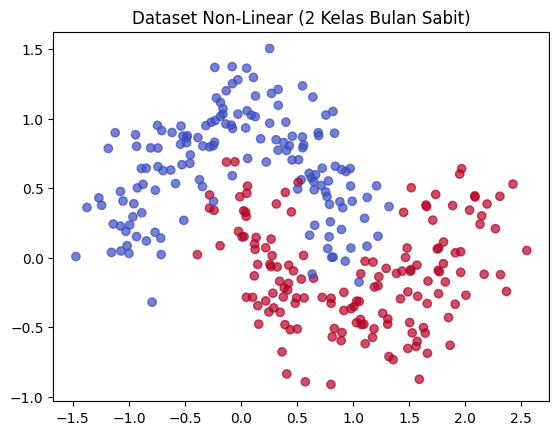

Keterangan Hasil:
Dataset terdiri dari dua kelas berbentuk bulan sabit yang saling melengkung dan bertautan.
Pola ini bersifat non-linear sehingga tidak dapat dipisahkan dengan satu garis lurus.


In [3]:
# ===================================================
# Langkah 1: Generate & Eksplorasi Dataset Non-Linear
# ===================================================

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

print("Keterangan Hasil:")
print("Dataset terdiri dari dua kelas berbentuk bulan sabit yang saling melengkung dan bertautan.")
print("Pola ini bersifat non-linear sehingga tidak dapat dipisahkan dengan satu garis lurus.")

In [6]:
# ===================================================
# Langkah 2: Bangun & Latih Neural Network Sederhana
# ===================================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.900


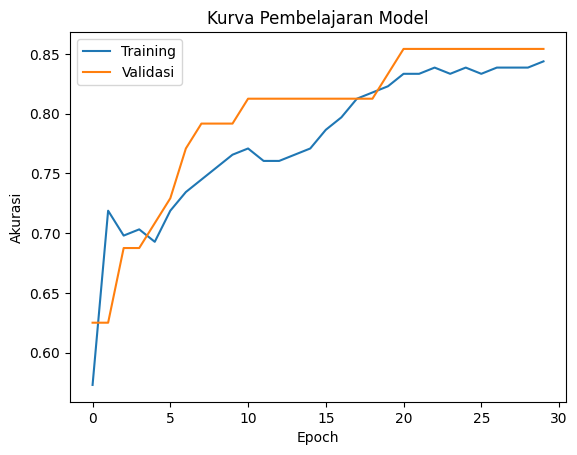

In [4]:
# ===============================================
# Langkah 3: Evaluasi & Visualisasi Kurva Belajar
# ===============================================

loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')

plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')

plt.show()

In [7]:
# ========================================
# Langkah 4: Siapkan Dataset Ulasan Produk
# ========================================

ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',

    'Produk sangat bagus dan berkualitas',
    'Barang tidak berfungsi dengan baik',
    'Pengiriman cepat dan barang memuaskan',
    'Pelayanan buruk dan sangat mengecewakan',

    'Saya suka produk ini',
    'Kualitas produk sangat rendah',
    'Barang sesuai dengan gambar',
    'Produk datang dalam kondisi rusak',
    'Harga murah dan kualitas bagus',

    'Sangat tidak puas dengan produk ini',
    'Produk sangat membantu dan mudah digunakan',
    'Barang terlambat dan kualitasnya buruk',
    'Pengemasan sangat rapi dan aman',
    'Produk tidak sesuai pesanan',

    'Sangat puas dengan pelayanan penjual',
    'Barang cepat rusak setelah digunakan',
    'Kualitas sangat baik untuk harganya',
    'Pengiriman sangat lambat',
    'Produk sesuai dengan harapan',

    'Barang mengecewakan dan tidak berkualitas',
    'Saya akan membeli produk ini lagi',
    'Produk tidak dapat digunakan',
    'Pelayanan ramah dan responsif',
    'Kualitas barang sangat buruk',

    'Produk bagus dan sangat memuaskan',
    'Barang tidak sesuai dengan foto',
    'Pengiriman aman dan tepat waktu',
    'Saya menyesal membeli produk ini',
    'Harga terjangkau dan produk berkualitas',

    'Barang datang dalam keadaan cacat',
    'Produk bekerja dengan sangat baik',
    'Sangat kecewa dengan pelayanan',
    'Penjual sangat ramah dan membantu',
    'Produk tidak sesuai dengan ekspektasi'
]

# 1 = Positif, 0 = Negatif
label = [
    1,0,1,0,1,0,
    1,0,1,0,
    1,0,1,0,1,
    0,1,0,1,0,
    1,0,1,0,1,
    0,1,0,1,0,
    1,0,1,0,1,
    0,1,0,1,0
]

print("Jumlah ulasan :", len(ulasan))
print("Jumlah label  :", len(label))
print("Positif       :", label.count(1))
print("Negatif       :", label.count(0))

Jumlah ulasan : 40
Jumlah label  : 40
Positif       : 20
Negatif       : 20


In [14]:
# ==========================================
# Langkah 5: Ubah Teks Menjadi TF-IDF
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 kata pertama:', tfidf.get_feature_names_out()[:10])
print('Ukuran matriks TF-IDF:', X_text.shape)
print("Teks ulasan berhasil diubah menjadi data numerik menggunakan TF-IDF, sehingga dapat digunakan sebagai input untuk model klasifikasi sentimen.")

# Menampilkan kata dan nilai TF-IDF
import pandas as pd

kata = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(
    X_text.toarray(),
    columns=kata
)

print("Daftar Kata dan Nilai TF-IDF:")
display(df_tfidf.head())

# Menghitung rata-rata nilai TF-IDF setiap kata
rata_tfidf = df_tfidf.mean().sort_values(ascending=False)

print("10 Kata dengan Nilai TF-IDF Tertinggi:")
display(
    rata_tfidf.head(10)
    .reset_index()
    .rename(columns={
        'index': 'Kata',
        0: 'Nilai TF-IDF'
    })
)


Jumlah kata unik: 70
10 kata pertama: ['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'bekerja'
 'beli' 'berfungsi']
Ukuran matriks TF-IDF: (40, 70)
Teks ulasan berhasil diubah menjadi data numerik menggunakan TF-IDF, sehingga dapat digunakan sebagai input untuk model klasifikasi sentimen.
Daftar Kata dan Nilai TF-IDF:


,akan,aman,bagus,baik,banget,barang,barangnya,bekerja,beli,berfungsi,...,sekali,sesuai,setelah,suka,tepat,terjangkau,terlambat,tidak,untuk,waktu
0,0.000000,0.0,0.392113,0.0,0.507859,0.000000,0.507859,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.348511,0.0,0.0,0.0,0.0,0.0,0.333919,0.0,0.0
2,0.478235,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.531875,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.000000,0.294498,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.391906,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


10 Kata dengan Nilai TF-IDF Tertinggi:


,Kata,Nilai TF-IDF
0,sangat,0.116023
1,produk,0.114669
2,dan,0.100882
3,dengan,0.088675
4,barang,0.087629
5,tidak,0.085361
6,sesuai,0.081051
7,kualitas,0.065421
8,pelayanan,0.049463
9,buruk,0.048970


In [11]:
# ======================================================
# Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi
# ======================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print('Hasil prediksi:', 'Positif' if pred[0] == 1 else 'Negatif')
# Prediksi data uji
hasil_prediksi = model_sentimen.predict(Xt_te)

print(f'Akurasi model sentimen: {akurasi:.3f}')

print("\nPerbandingan Label Aktual dan Prediksi:")
for i, (aktual, prediksi) in enumerate(zip(yt_te, hasil_prediksi), 1):
    print(
        f"Data {i}: Aktual = {'Positif' if aktual == 1 else 'Negatif'} | "
        f"Prediksi = {'Positif' if prediksi == 1 else 'Negatif'}"
    )

# Uji kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print("\nKalimat baru:", kalimat_baru[0])
print("Hasil prediksi:", 'Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.500
Hasil prediksi: Positif
Akurasi model sentimen: 0.500

Perbandingan Label Aktual dan Prediksi:
Data 1: Aktual = Negatif | Prediksi = Negatif
Data 2: Aktual = Positif | Prediksi = Positif
Data 3: Aktual = Negatif | Prediksi = Positif
Data 4: Aktual = Positif | Prediksi = Positif
Data 5: Aktual = Positif | Prediksi = Negatif
Data 6: Aktual = Positif | Prediksi = Negatif
Data 7: Aktual = Negatif | Prediksi = Positif
Data 8: Aktual = Negatif | Prediksi = Negatif

Kalimat baru: Pelayanan sangat memuaskan dan ramah
Hasil prediksi: Positif


Kesimpulan:

Praktikum Pertemuan 13 membahas penerapan Deep Learning dan NLP. Neural Network digunakan untuk mengenali pola data non-linear, sedangkan TF-IDF digunakan untuk mengubah teks menjadi data numerik agar dapat dianalisis. Selanjutnya, Logistic Regression digunakan untuk mengklasifikasikan ulasan menjadi sentimen positif atau negatif. Hasil pengujian memperoleh akurasi 50% dan kalimat baru berhasil diprediksi sebagai sentimen positif. Secara keseluruhan, praktikum ini menunjukkan bagaimana model dapat mempelajari pola data serta mengolah teks untuk melakukan klasifikasi dan prediksi.